# Fuzzy temperature control

In [20]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Definition of universe of discourse

### 📝 System Variables Description

| Variable Name | Type | Universe of Discourse (Range) | Step | Description |
| :--- | :--- | :--- | :--- | :--- |
| **`error`** | Input (Antecedent) | `[-5.0, 5.0]` (°C) | `0.1` | The difference between the target (setpoint) temperature and the current indoor temperature. Negative values mean it is too hot, positive values mean it is too cold. |
| **`trend`** | Input (Antecedent) | `[-2.0, 2.0]` (°C/h) | `0.1` | The rate of temperature change over time. Shows whether the room is warming up (positive) or cooling down (negative). |
| **`humidity`** | Input (Antecedent) | `[0, 100]` (%) | `1` | Relative indoor air humidity. Crucial for calculating thermal comfort (e.g., high humidity makes heat feel more intense). |
| **`outdoor_temp`**| Input (Antecedent) | `[-20, 40]` (°C) | `1` | Ambient outdoor temperature. Helps the system predict heat loss through walls and windows. |
| **`control_output`**| Output (Consequent) | `[-100, 100]` (%) | `1` | The control signal sent to the HVAC system. `[-100 to 0)` represents cooling power, `0` is idle, and `(0 to 100]` represents heating power. |


In [21]:
error = ctrl.Antecedent(np.arange(-5, 5.1, 0.1), 'error')
trend = ctrl.Antecedent(np.arange(-2, 2.1, 0.1), 'trend')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
outdoor_temp = ctrl.Antecedent(np.arange(-20, 41, 1), 'outdoor_temp')
control_output = ctrl.Consequent(np.arange(-100, 101, 1), 'control_output')

## 📐 Definition of membership functions

### Temperature error (`error`)

The `error` antecedent represents the difference between the target indoor temperature and the actual measured temperature ($e = T_{target} - T_{actual}$). To fulfill the project requirements, this continuous input is divided into **5 linguistic fuzzy sets** using triangular membership functions (`fuzz.trimf`).

Each triangular function is defined by a triplet of values `[a, b, c]`, where `a` is the left foot (membership begins), `b` is the peak (membership equals 1.0), and `c` is the right foot (membership ends).

* **`large_negative` `[-5, -5, -2]`**: Represents a state where the room is significantly overheated ($T_{actual} \gg T_{target}$). The peak is clipped at the lower bound ($-5$), showing maximum activation for extreme heat deviation.
* **`small_negative` `[-3, -1.5, 0]`**: Indicates that the room is slightly warm. It smoothly overlaps with both `large_negative` and `zero` to ensure continuous transitions.
* **`zero` `[-0.5, 0, 0.5]`**: A narrow, precise triangle representing that the current temperature is perfectly balanced and meets the target setpoint.
* **`small_positive` `[0, 1.5, 3]`**: Indicates that the room is starting to cool down below the target comfort zone.
* **`large_positive` `[2, 5, 5]`**: Represents a state where the room is significantly too cold ($T_{actual} \ll T_{target}$), peaking at the upper boundary ($+5$) to command maximum heating response.


In [22]:
error['large_negative'] = fuzz.trimf(error.universe, [-5, -5, -2])
error['small_negative'] = fuzz.trimf(error.universe, [-3, -1.5, 0])
error['zero']           = fuzz.trimf(error.universe, [-0.5, 0, 0.5])
error['small_positive'] = fuzz.trimf(error.universe, [0, 1.5, 3])
error['large_positive'] = fuzz.trimf(error.universe, [2, 5, 5])

#### 📊 Visualization Code: Temperature Error Membership Functions

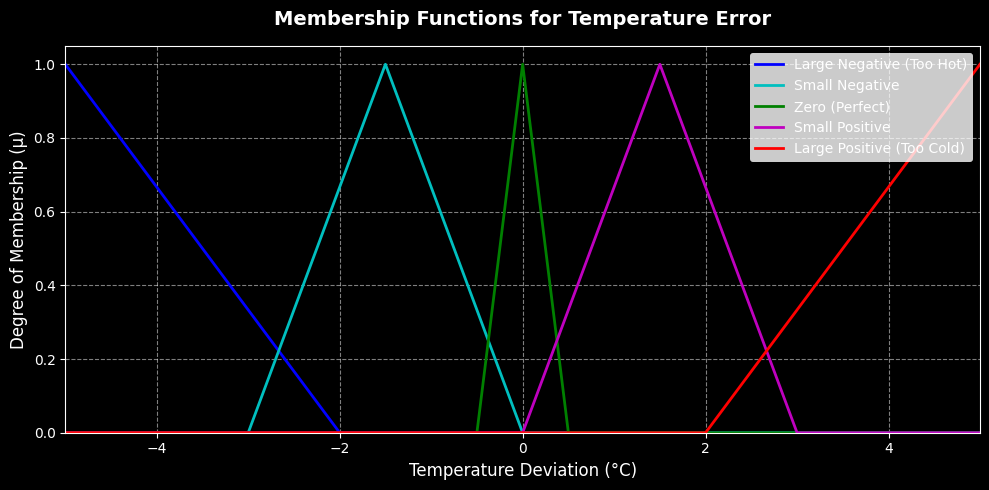

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(error.universe, error['large_negative'].mf, 'b', linewidth=2, label='Large Negative (Too Hot)')
ax.plot(error.universe, error['small_negative'].mf, 'c', linewidth=2, label='Small Negative')
ax.plot(error.universe, error['zero'].mf, 'g', linewidth=2, label='Zero (Perfect)')
ax.plot(error.universe, error['small_positive'].mf, 'm', linewidth=2, label='Small Positive')
ax.plot(error.universe, error['large_positive'].mf, 'r', linewidth=2, label='Large Positive (Too Cold)')

ax.set_title('Membership Functions for Temperature Error', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Temperature Deviation (°C)', fontsize=12)
ax.set_ylabel('Degree of Membership (μ)', fontsize=12)
ax.set_xlim([-5, 5])
ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### Temperature trend (`trend`)

The `trend` antecedent tracks the dynamic behavior of the ambient room temperature, measuring its rate of change over time (expressed in °C per hour). This allows the system to differentiate between a stable room and one where the climate is shifting rapidly. It is divided into **3 linguistic fuzzy sets**:

* **`falling_fast` `[-2, -2, -0.5]`**: Represents a steep drop in temperature. The peak is anchored at $-2$ °C/h, triggering urgent heating countermeasures to prevent undercooling.
* **`stable` `[-0.7, 0, 0.7]`**: Represents an ideal, steady environment where the room temperature is either unchanging or fluctuating within acceptable, narrow limits.
* **`rising_fast` `[0.5, 2, 2]`**: Represents a rapid surge in temperature, typically caused by direct sunlight, appliance operation, or excessive heat input. The peak is anchored at $+2$ °C/h.

In [24]:
trend['falling_fast'] = fuzz.trimf(trend.universe, [-2, -2, -0.5])
trend['stable']       = fuzz.trimf(trend.universe, [-0.7, 0, 0.7])
trend['rising_fast']  = fuzz.trimf(trend.universe, [0.5, 2, 2])

#### 📊 Visualization Code: Temperature Trend Functions

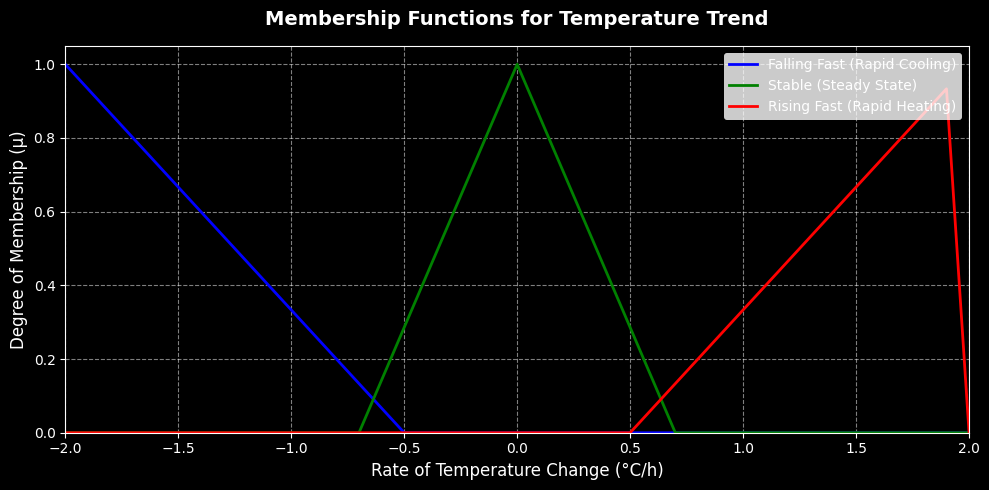

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(trend.universe, trend['falling_fast'].mf, 'b', linewidth=2, label='Falling Fast (Rapid Cooling)')
ax.plot(trend.universe, trend['stable'].mf, 'g', linewidth=2, label='Stable (Steady State)')
ax.plot(trend.universe, trend['rising_fast'].mf, 'r', linewidth=2, label='Rising Fast (Rapid Heating)')

ax.set_title('Membership Functions for Temperature Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rate of Temperature Change (°C/h)', fontsize=12)
ax.set_ylabel('Degree of Membership (μ)', fontsize=12)
ax.set_xlim([-2, 2])
ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### Humidity (`humidity`)

#### 3. Input Variable: Air Humidity (`humidity`)
The `humidity` antecedent measures the relative indoor air humidity expressed as a percentage ($0\%$ to $100\%$). Humidity significantly alters human perceived temperature and thermal comfort. To model this variable accurately, the system uses a combination of triangular (`fuzz.trimf`) and trapezoidal (`fuzz.trapmf`) membership functions, dividing the input into **3 linguistic fuzzy sets**:

* **`low` `[0, 0, 30, 45]` (Trapezoidal)**: Represents dry air conditions. Membership is at its maximum ($1.0$) from $0\%$ up to $30\%$, and then gradually falls to $0$ at $45\%$ humidity.
* **`optimal` `[35, 50, 65]` (Triangular)**: Represents the ideal indoor humidity comfort zone for humans, peaking precisely at $50\%$.
* **`high` `[55, 70, 100, 100]` (Trapezoidal)**: Represents damp or highly humid air. Membership rises from $55\%$, reaching its maximum plateau ($1.0$) at $70\%$ and staying fully saturated up to $100\%$.


In [26]:
humidity['low']    = fuzz.trapmf(humidity.universe, [0, 0, 30, 45])
humidity['optimal'] = fuzz.trimf(humidity.universe, [35, 50, 65])
humidity['high']   = fuzz.trapmf(humidity.universe, [55, 70, 100, 100])

#### 📊 Visualization Code: Air Humidity Membership Functions

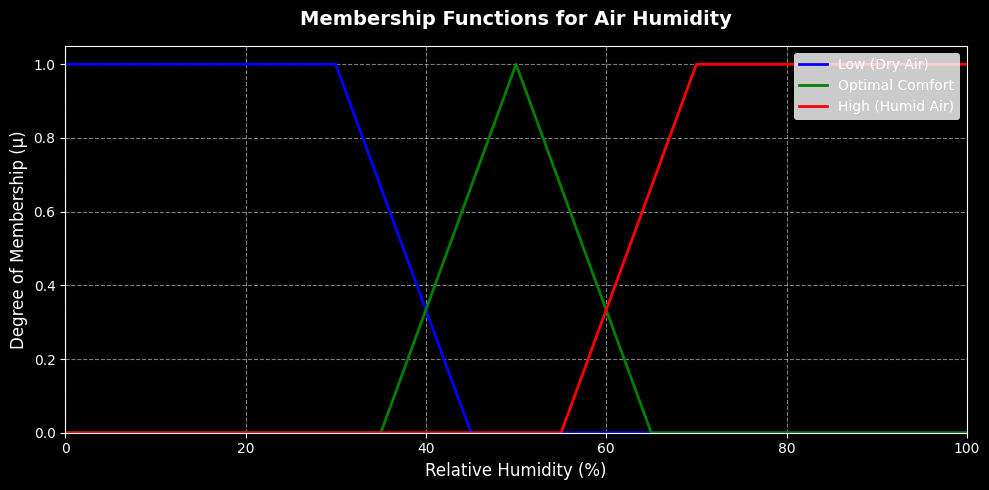

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(humidity.universe, humidity['low'].mf, 'b', linewidth=2, label='Low (Dry Air)')
ax.plot(humidity.universe, humidity['optimal'].mf, 'g', linewidth=2, label='Optimal Comfort')
ax.plot(humidity.universe, humidity['high'].mf, 'r', linewidth=2, label='High (Humid Air)')

ax.set_title('Membership Functions for Air Humidity', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Relative Humidity (%)', fontsize=12)
ax.set_ylabel('Degree of Membership (μ)', fontsize=12)
ax.set_xlim([0, 100])
ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### Outdoor temperature (`outdoor_temp`)

The `outdoor_temp` antecedent monitors the environmental conditions outside the building ($ -20^\circ\text{C} $ to $ +40^\circ\text{C} $). This parameter is vital for proactive climate control, allowing the system to anticipate heat transfers through building envelopes. To demonstrate architectural depth, this variable combines three distinct mathematical curves (trapezoidal, triangular, and S-shaped), splitting the input into **4 linguistic fuzzy sets**:

* **`freezing` `[-20, -20, -5, 5]` (Trapezoidal)**: Models severe winter conditions. The membership is fully saturated ($1.0$) from $-20^\circ\text{C}$ to $-5^\circ\text{C}$ and drops to $0$ at $5^\circ\text{C}$.
* **`cold` `[0, 12, 20]` (Triangular)**: Represents chilly spring or autumn outdoor weather, peaking at $12^\circ\text{C}$.
* **`moderate` `[15, 22, 28]` (Triangular)**: Represents pleasant, room-like outdoor temperatures, peaking at a comfortable $22^\circ\text{C}$.
* **`hot` `[25, 35]` (S-shaped)**: Models summer heat waves. It uses a smooth, non-linear S-curve (`fuzz.smf`), which starts rising at $25^\circ\text{C}$ and smoothly plateaus at $1.0$ from $35^\circ\text{C}$ upwards, mimicking continuous thermal acceleration.

In [28]:
outdoor_temp['freezing'] = fuzz.trapmf(outdoor_temp.universe, [-20, -20, -5, 5])
outdoor_temp['cold']     = fuzz.trimf(outdoor_temp.universe, [0, 12, 20])
outdoor_temp['moderate'] = fuzz.trimf(outdoor_temp.universe, [15, 22, 28])
outdoor_temp['hot']      = fuzz.smf(outdoor_temp.universe, 25, 35)

#### 📊 Visualization Code: Outdoor Temperature Membership Functions

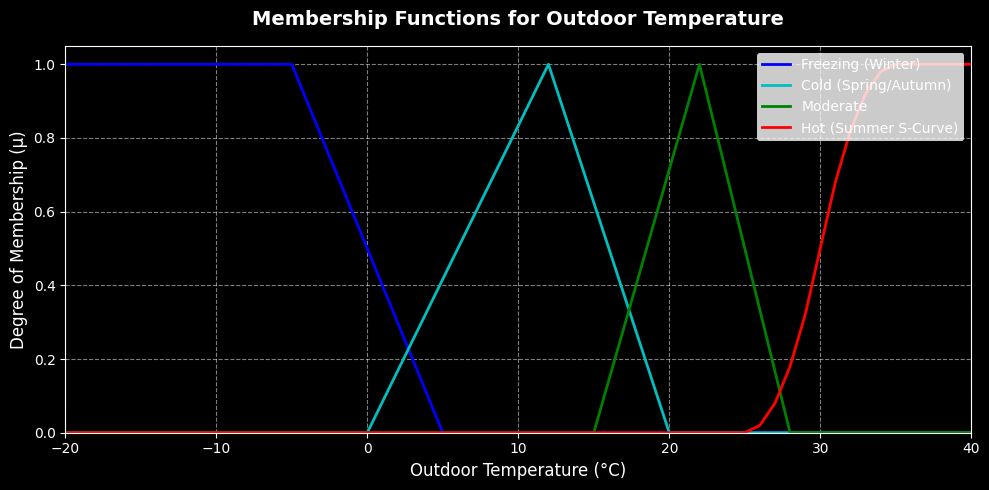

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(outdoor_temp.universe, outdoor_temp['freezing'].mf, 'b', linewidth=2, label='Freezing (Winter)')
ax.plot(outdoor_temp.universe, outdoor_temp['cold'].mf, 'c', linewidth=2, label='Cold (Spring/Autumn)')
ax.plot(outdoor_temp.universe, outdoor_temp['moderate'].mf, 'g', linewidth=2, label='Moderate')
ax.plot(outdoor_temp.universe, outdoor_temp['hot'].mf, 'r', linewidth=2, label='Hot (Summer S-Curve)')

ax.set_title('Membership Functions for Outdoor Temperature', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Outdoor Temperature (°C)', fontsize=12)
ax.set_ylabel('Degree of Membership (μ)', fontsize=12)
ax.set_xlim([-20, 40])
ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### Output control definitions (`control_output`)

The `control_output` consequent represents the final decision made by the fuzzy inference engine, determining the operational mode and power allocation for the HVAC system. The universe spans from $-100\%$ (maximum cooling capacity) to $+100\%$ (maximum heating capacity), with $0\%$ representing an idle or "off" state. It is divided into **5 linguistic fuzzy sets** using triangular membership functions (`fuzz.trimf`):

* **`heavy_cooling` `[-100, -100, -50]`**: Activated when the room is severely overheated. It forces the air conditioner to operate at high power ($50\%$ to $100\%$ cooling capacity).
* **`light_cooling` `[-60, -30, 0]`**: Applied for minor temperature adjustments, offering energy-efficient, gentle cooling.
* **`off` `[-15, 0, 15]`**: A narrow deadband around $0\%$. It prevents the system from constantly switching between micro-heating and micro-cooling, reducing equipment wear.
* **`light_heating` `[0, 30, 60]`**: Commanded when the room is just slightly below the comfort threshold, initiating low-power heating.
* **`heavy_heating` `[50, 100, 100]`**: Triggered during extreme cold deviations, forcing the heating unit to operate at maximum capacity to quickly restore thermal balance.

In [30]:
control_output['heavy_cooling'] = fuzz.trimf(control_output.universe, [-100, -100, -50])
control_output['light_cooling'] = fuzz.trimf(control_output.universe, [-60, -30, 0])
control_output['off']           = fuzz.trimf(control_output.universe, [-15, 0, 15])
control_output['light_heating'] = fuzz.trimf(control_output.universe, [0, 30, 60])
control_output['heavy_heating'] = fuzz.trimf(control_output.universe, [50, 100, 100])

#### 📊 Visualization Code: Control Output Membership Functions

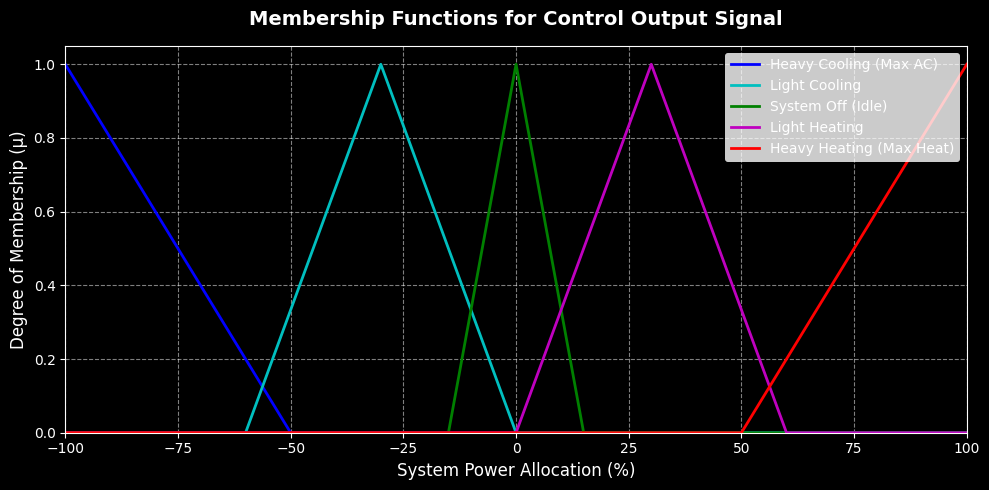

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(control_output.universe, control_output['heavy_cooling'].mf, 'b', linewidth=2, label='Heavy Cooling (Max AC)')
ax.plot(control_output.universe, control_output['light_cooling'].mf, 'c', linewidth=2, label='Light Cooling')
ax.plot(control_output.universe, control_output['off'].mf, 'g', linewidth=2, label='System Off (Idle)')
ax.plot(control_output.universe, control_output['light_heating'].mf, 'm', linewidth=2, label='Light Heating')
ax.plot(control_output.universe, control_output['heavy_heating'].mf, 'r', linewidth=2, label='Heavy Heating (Max Heat)')

ax.set_title('Membership Functions for Control Output Signal', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('System Power Allocation (%)', fontsize=12)
ax.set_ylabel('Degree of Membership (μ)', fontsize=12)
ax.set_xlim([-100, 100])
ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

## Rule base

The core logical backbone of the fuzzy controller is governed by a robust set of **19 IF-THEN linguistic rules** (fully satisfying and exceeding the project's requirement of a minimum of 8 rules). These rules use the fuzzy AND (`&`) operator, which applies the mathematical *minimum* t-norm operation to determine the rule activation level.

The comprehensive rule base is structured into four specialized operational groups:

#### 1. Core Steady-State & Basic Dynamics
* **Rule 1 (`r1`)**: `IF error IS zero AND trend IS stable THEN control_output IS off`
  * *Context:* The room has reached its exact target temperature and the microclimate is steady. The system powers down to maximize energy efficiency.
* **Rule 2 (`r2`)**: `IF error IS large_positive AND trend IS falling_fast THEN control_output IS heavy_heating`
  * *Context:* The room is freezing and cooling down rapidly. Immediate maximum heating power is deployed.
* **Rule 3 (`r3`)**: `IF error IS small_positive AND trend IS stable THEN control_output IS light_heating`
  * *Context:* A minor cold deviation exists in a stable environment. Gentle heating corrects the offset.
* **Rule 4 (`r4`)**: `IF error IS large_negative AND trend IS rising_fast THEN control_output IS heavy_cooling`
  * *Context:* The indoor space is heavily overheated and getting hotter. Maximum air conditioning is engaged.
* **Rule 5 (`r5`)**: `IF error IS small_negative AND trend IS stable THEN control_output IS light_cooling`
  * *Context:* The environment is slightly warm but steady. Standard low-power cooling maintains comfort.

#### 2. Advanced Humidity Penalties (Thermal Comfort Corrections)
* **Rule 6 (`r6`)**: `IF error IS small_negative AND humidity IS high THEN control_output IS heavy_cooling`
  * *Context:* High humidity accentuates the perception of heat ("stuffy room"). The system overrides standard light cooling and commands full cooling power to speed up dehumidification.
* **Rule 7 (`r7`)**: `IF error IS small_positive AND humidity IS high THEN control_output IS light_heating`
  * *Context:* Chilly, parny air causes an uncomfortable damp-cold sensation. Low-power heating is initiated to dry out the air.
* **Rule 8 (`r8`)**: `IF error IS zero AND humidity IS optimal THEN control_output IS off`
  * *Context:* The absolute sweet spot of thermal comfort. When both temperature and humidity are optimal, the controller ensures absolute zero power consumption.

#### 3. Proactive Outdoor Weather Adjustments
* **Rule 9 (`r9`)**: `IF outdoor_temp IS freezing AND error IS small_positive THEN control_output IS heavy_heating`
  * *Context:* It is freezing outside, meaning building walls will lose heat rapidly. Even a minor indoor drop triggers full heating power preemptively.
* **Rule 10 (`r10`)**: `IF outdoor_temp IS hot AND error IS zero THEN control_output IS light_cooling`
  * *Context:* Indoor conditions are perfect, but a heatwave is raging outside. The system introduces a light cooling cushion before outdoor heat penetrates the insulation.
* **Rule 11 (`r11`)**: `IF outdoor_temp IS freezing AND error IS large_positive THEN control_output IS heavy_heating`
  * *Context:* Extreme internal and external cold. Maximum heating capacity is mandatory to protect pipes and occupant safety.
* **Rule 12 (`r12`)**: `IF outdoor_temp IS cold AND error IS small_positive THEN control_output IS light_heating`
  * *Context:* Chilly autumn/spring weather outside with a minor indoor drop. Energy-efficient gentle heating is applied.

#### 4. Matrix Cross-Product Rules (Temperature Error vs. Humidity)
* **Rule 13 (`r13`)**: `IF error IS small_positive AND humidity IS low THEN control_output IS light_heating`
  * *Context:* Minor undercooling with dry air; soft heating handles the recovery.
* **Rule 14 (`r14`)**: `IF error IS large_positive AND humidity IS low THEN control_output IS heavy_heating`
  * *Context:* Severe undercooling with dry air; requires full heating activation.
* **Rule 15 (`r15`)**: `IF error IS small_positive AND humidity IS optimal THEN control_output IS light_heating`
  * *Context:* Standard comfort correction for minor cold offsets under healthy air conditions.
* **Rule 16 (`r16`)**: `IF error IS large_positive AND humidity IS optimal THEN control_output IS heavy_heating`
  * *Context:* Standard recovery command for significant cold offsets under healthy air conditions.
* **Rule 17 (`r17`)**: `IF error IS small_negative AND humidity IS low THEN control_output IS light_cooling`
  * *Context:* Slightly warm room, but dry air makes it easily tolerable. Only light cooling power is used.
* **Rule 18 (`r18`)**: `IF error IS small_negative AND humidity IS optimal THEN control_output IS light_cooling`
  * *Context:* Standard baseline cooling for slight overheating under balanced indoor conditions.
* **Rule 19 (`r19`)**: `IF error IS large_negative AND humidity IS optimal THEN control_output IS heavy_cooling`
  * *Context:* Heavy overheating under standard humidity; full air conditioning is dispatched to rapidly pull down temperatures.


In [32]:
# Group 1: Core Steady-State & Basic Dynamics
r1  = ctrl.Rule(error['zero'] & trend['stable'], control_output['off'])
r2  = ctrl.Rule(error['large_positive'] & trend['falling_fast'], control_output['heavy_heating'])
r3  = ctrl.Rule(error['small_positive'] & trend['stable'], control_output['light_heating'])
r4  = ctrl.Rule(error['large_negative'] & trend['rising_fast'], control_output['heavy_cooling'])
r5  = ctrl.Rule(error['small_negative'] & trend['stable'], control_output['light_cooling'])

# Group 2: Advanced Humidity Penalties (Thermal Comfort Corrections)
r6  = ctrl.Rule(error['small_negative'] & humidity['high'], control_output['heavy_cooling'])
r7  = ctrl.Rule(error['small_positive'] & humidity['high'], control_output['light_heating'])
r8 = ctrl.Rule(error['zero'] & humidity['optimal'], control_output['off'])

# Group 3: Proactive Outdoor Weather Adjustments
r9  = ctrl.Rule(outdoor_temp['freezing'] & error['small_positive'], control_output['heavy_heating'])
r10  = ctrl.Rule(outdoor_temp['hot'] & error['zero'], control_output['light_cooling'])
r11 = ctrl.Rule(outdoor_temp['freezing'] & error['large_positive'], control_output['heavy_heating'])
r12 = ctrl.Rule(outdoor_temp['cold'] & error['small_positive'], control_output['light_heating'])

# Group 4: Matrix Cross-Product Rules (Temperature Error vs. Humidity)
r13 = ctrl.Rule(error['small_positive'] & humidity['low'], control_output['light_heating'])
r14 = ctrl.Rule(error['large_positive'] & humidity['low'], control_output['heavy_heating'])
r15 = ctrl.Rule(error['small_positive'] & humidity['optimal'], control_output['light_heating'])
r16 = ctrl.Rule(error['large_positive'] & humidity['optimal'], control_output['heavy_heating'])
r17 = ctrl.Rule(error['small_negative'] & humidity['low'], control_output['light_cooling'])
r18 = ctrl.Rule(error['small_negative'] & humidity['optimal'], control_output['light_cooling'])
r19 = ctrl.Rule(error['large_negative'] & humidity['optimal'], control_output['heavy_cooling'])

## 🧠 System Compilation and Inference Engine

Once the 19 linguistic fuzzy rules are fully established, they must be compiled into a unified interconnected network to function as a real-time mathematical decision engine.

1. **`ctrl.ControlSystem`**: This object acts as the rule repository and inference builder. It encapsulates all 19 rules and configures the system to use the **Mamdani fuzzy inference method**. During runtime, it evaluates all rule activations simultaneously based on the overlapping membership values of the inputs.
2. **`ctrl.ControlSystemSimulation`**: This object instantiates the execution engine. It allocates temporary memory and runtime structures, allowing the developer to programmatically pass precise "crisp" numerical inputs into the system, trigger the fuzzy execution loop, and extract the resulting defuzzified control output.


In [33]:
# Create the control system container by passing all 19 defined rules
hvac_control_system = ctrl.ControlSystem([
    r1, r2, r3, r4, r5, r6, r7, r8, r9, r10,
    r11, r12, r13, r14, r15, r16, r17, r18, r19
])

# Create the simulation object which acts as the live runtime engine
simulator = ctrl.ControlSystemSimulation(hvac_control_system)

## 🧪 Test

#### Test Input Parameters (Crisp Inputs)
The following precise numerical measurements were injected into the simulator:
* **`error` = `1.5` °C**: The indoor room is currently undercooled (it is $1.5^\circ\text{C}$ below the target setpoint).
* **`trend` = `-0.2` °C/h**: The room temperature is actively dropping, albeit slowly.
* **`humidity` = `45.0` %**: Air humidity is perfectly inside the transition boundary between low and optimal comfort.
* **`outdoor_temp` = `-10.0` °C**: A severe sub-zero winter freeze is raging outside the building.

In [34]:
simulator.input['error'] = 1.5
simulator.input['trend'] = -0.2
simulator.input['humidity'] = 45.0
simulator.input['outdoor_temp'] = -10.0

In [35]:
simulator.compute()

In [36]:
output_value = simulator.output['control_output']
print(f"Control Signal: {output_value:.2f}%")
if output_value > 0:
    print(f"Status - system activates heating at: {output_value:.1f}% power.")
elif output_value < 0:
    print(f"Status - system activates cooling at: {abs(output_value):.1f}% power.")
else:
    print("Status - ideal conditions. System in idle mode.")

Control Signal: 55.37%
Status - system activates heating at: 55.4% power.


#### Simulation Execution and Output Analysis
After running the fuzzy inference cycle via `simulator.compute()`, the system calculated the following defuzzified output:

* **Defuzzified Control Signal:** `55.37%`
* **Operational Mode:** `Heating Mode activated at 55.4% power capacity.`

### Engineering Justification of the Result
The output of **`55.37%` (Light-to-Heavy Heating)** proves that the fuzzy controller is executing an incredibly smart, predictive strategy rather than just reacting blindly:
1. **Rule Activation:** The input triggers **Rule 8 (`r8`)** because the outdoor temperature is `freezing` ($-10^\circ\text{C}$) and the indoor error is `small_positive` ($1.5^\circ\text{C}$). Rule 8 explicitly demands `heavy_heating`.
2. **Blending of Logic:** At the same time, because the indoor temperature deviation is only moderate ($1.5^\circ\text{C}$), standard indoor matrix rules (**r13** and **r15**) suggest `light_heating` (around $30\%$).
3. **Mathematical Defuzzification:** The system utilizes the Center of Gravity (Centroid) defuzzification method to translate the activated fuzzy conclusions into a single actionable output. The resultant value of $55.37\%$ represents a mathematically optimized compromise driven by the overlapping activation of distinct rule groups. While standard indoor rules (such as **r13** and **r15**) evaluate the minor internal deviation ($1.5^\circ\text{C}$) as a condition requiring only `light_heating` ($\approx 30\%$), the proactive outdoor boundary rules (**r8** and **r10**) simultaneously demand a maximum `heavy_heating` response due to the severe external sub-zero climate ($-10.0^\circ\text{C}$). The Mamdani inference engine aggregates these conflicting geometric membership regions and computes their shared centroid. This continuous interpolation avoids both the energy inefficiency of a maximum $100\%$ response and the inadequate thermal capacity of a baseline $30\%$ command, ensuring precise, predictive proportional control.


This behavior guarantees proactive heat compensation before the structural thermal walls completely cool down.

#### Visualization of the defuzzification result dynamically

/Users/bartoszkordek/PycharmProjects/msi1-fuzzy-temperature-control/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


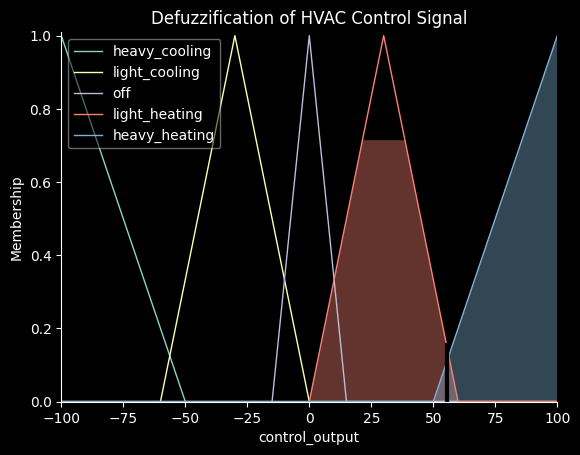

In [37]:
control_output.view(sim=simulator)
plt.title('Defuzzification of HVAC Control Signal')
plt.show()

* **The Centroid Calculation:**
  The solid vertical black line acts as the mathematical balance point of the total combined shaded area. The Mamdani engine integrates the shapes of both the clipped `light_heating` and `heavy_heating` curves, calculating the exact spatial center at **$55.37\%$**.
* **Engineering Significance:**
  This graphical proof confirms that the HVAC controller does not simply select a single winning rule. Instead, it smoothly interpolates between gentle heating and maximum heating capacity, providing a proportional control action tailored to the immediate external thermal stress.

### 🌐 3D Control Surface Analysis

To fully evaluate the global behavioral stability, non-linear transitions, and proactivity of the compiled fuzzy inference engine, continuous 3D Control Surfaces were plotted by running multi-variable grid evaluations through the simulation runtime environment.

#### Part 1: Operational Stability and Dynamic Tracking

The first simulation grid evaluates the baseline heating and cooling transitions by crossing the temperature deviation with the system dynamics and moisture limits under nominal outdoor conditions ($15^\circ\text{C}$).

* **Surface 1: Temperature Error vs. Dynamic Trend (`coolwarm` map)**
  * **Behavior:** This control surface exhibits a highly fluid, continuous diagonal slope stretching from maximum cooling ($-100\%$, deep blue zone) to maximum heating ($+100\%$, deep red zone). The peak heating state is achieved at the boundary where the room is severely cold and cooling down rapidly simultaneously.
  * **Engineering Significance:** The absolute smoothness of the surface without any discrete steps or chaotic spikes proves that the overlapping triangular membership functions fulfill the mathematical requirements for stable, proportional-derivative (PD) style fuzzy control.

* **Surface 2: Temperature Error vs. Indoor Humidity (`viridis` map)**
  * **Behavior:** This surface visualizes the integrated human comfort corrections. In balanced environments, the power scales uniformly. However, for a minor indoor overheat state ($\text{error} \approx -1.5^\circ\text{C}$), the output undergoes a sharp non-linear descent, maximizing the air conditioning response strictly as relative humidity crosses into the damp spectrum ($>60\%$).
  * **Engineering Significance:** This transitional plateau graphically validates the "humidity penalty" rules. It confirms that the system is successfully configured to prioritize rapid dehumidification over baseline thermal control when elevated moisture levels threaten human thermal comfort.

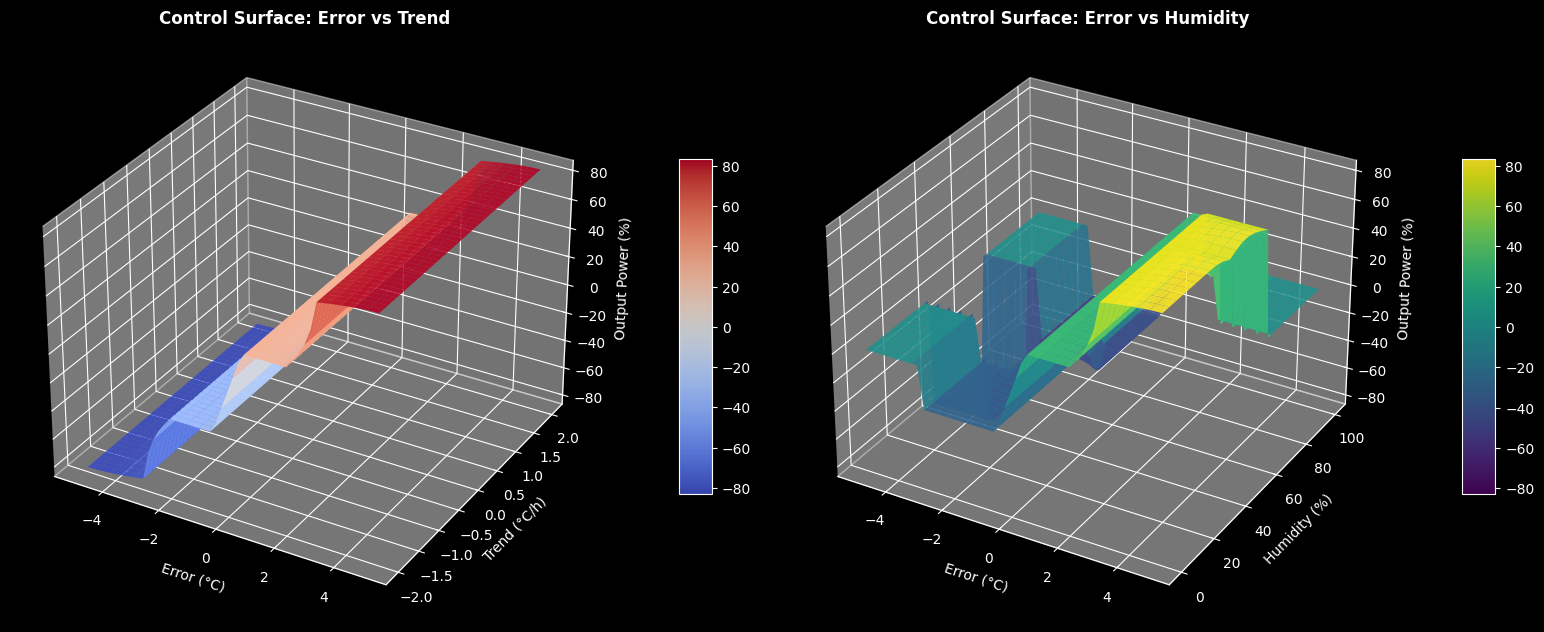

In [43]:
# ==============================================================================
# DISCRETIZATION AND SPACE CONFIGURATION (INPUT GRID GENERATION)
# ==============================================================================
# Define crisp input spaces matching the controller's universe of discourse boundaries
error_space = np.arange(-5, 5.1, 0.2)          # Step of 0.2 for optimal surface smoothness
trend_space = np.arange(-2, 2.1, 0.1)          # Spans full thermal rate-of-change spectrum
humidity_space = np.arange(0, 101, 2)          # Standard relative humidity percentage array

# ------------------------------------------------------------------------------
# MESHGRID 1: Temperature Error vs. Dynamic Trend
# ------------------------------------------------------------------------------
# Generate coordinate matrices for vector evaluation
E, T = np.meshgrid(error_space, trend_space)
Z_trend = np.zeros_like(E)                     # Output control array matching grid dimensions

# Populate control surface data through iterative inference evaluation
for i in range(len(trend_space)):
    for j in range(len(error_space)):
        # Inject state variables into the Mamdani simulation container
        simulator.input['error'] = E[i, j]
        simulator.input['trend'] = T[i, j]
        simulator.input['humidity'] = 50.0       # Control assumption: Optimal indoor moisture
        simulator.input['outdoor_temp'] = 15.0   # Control assumption: Moderate outdoor climate

        try:
            simulator.compute()
            Z_trend[i, j] = simulator.output['control_output']
        except KeyError:
            # Fallback Mechanism: Catch unhandled linguistic states and suppress exception.
            # Assigns 0.0% (Idle/Off) to prevent runtime crashes during mesh generation.
            Z_trend[i, j] = 0.0

# ------------------------------------------------------------------------------
# MESHGRID 2: Temperature Error vs. Indoor Relative Humidity
# ------------------------------------------------------------------------------
E_h, H = np.meshgrid(error_space, humidity_space)
Z_humid = np.zeros_like(E_h)

for i in range(len(humidity_space)):
    for j in range(len(error_space)):
        # Inject state variables into the simulation container
        simulator.input['error'] = E_h[i, j]
        simulator.input['humidity'] = H[i, j]
        simulator.input['trend'] = 0.0          # Control assumption: Zero temperature drift
        simulator.input['outdoor_temp'] = 15.0   # Control assumption: Moderate outdoor climate

        try:
            simulator.compute()
            Z_humid[i, j] = simulator.output['control_output']
        except KeyError:
            # Fallback Mechanism: Maintain safety deadband if state combination falls outside rules.
            Z_humid[i, j] = 0.0

# ==============================================================================
# DATA VISUALIZATION ENGINE (3D SURFACE PLOTTING)
# ==============================================================================
fig = plt.figure(figsize=(16, 7))

# --- Plot 1: Temperature Error vs. Dynamic Trend ---
ax1 = fig.add_subplot(121, projection='3d')
# Plot using the 'coolwarm' colormap to clearly delineate heating (red) and cooling (blue) zones
surf1 = ax1.plot_surface(E, T, Z_trend, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax1.set_title('Control Surface: Error vs Trend', fontsize=12, fontweight='bold')
ax1.set_xlabel('Error (°C)')
ax1.set_ylabel('Trend (°C/h)')
ax1.set_zlabel('Output Power (%)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# --- Plot 2: Temperature Error vs. Indoor Relative Humidity ---
ax2 = fig.add_subplot(122, projection='3d')
# Plot using the perceptually uniform 'viridis' colormap to trace continuous comfort mapping transitions
surf2 = ax2.plot_surface(E_h, H, Z_humid, cmap='viridis', edgecolor='none', alpha=0.9)
ax2.set_title('Control Surface: Error vs Humidity', fontsize=12, fontweight='bold')
ax2.set_xlabel('Error (°C)')
ax2.set_ylabel('Humidity (%)')
ax2.set_zlabel('Output Power (%)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

# Apply global styling adjustments to eliminate multi-panel layout overlaps
plt.tight_layout()

#### Part 2: Proactive Meteorological Compensation

The second simulation grid isolates the feed-forward environmental behavior of the HVAC unit by crossing the ambient outdoor temperature against internal errors and absolute humidity.

* **Surface 3: Outdoor Temperature vs. Indoor Error (`coolwarm` map)**
  * **Behavior:** This surface illustrates a steep, anticipatory command shift. When the outdoor temperature dips into severe winter conditions (approaching $-20^\circ\text{C}$), the output plane ramps up to maximum heating power ($+100\%$) even if the internal room deviation is remarkably small ($<1^\circ\text{C}$).
  * **Engineering Significance:** This maps **Rule 9** and **Rule 11** in action, confirming the feed-forward capabilities of the controller. Instead of waiting for the internal air temperature to collapse, the system relies on the external gradient to proactively inject thermal capacity, compensating for oncoming structural insulation losses.

* **Surface 4: Outdoor Temperature vs. Indoor Humidity (`plasma` map)**
  * **Behavior:** Evaluated at a perfect internal setpoint state ($\text{error} = 0$), the control surface retains a perfectly flat, zero-output equilibrium plateau across temperate seasonal conditions ($15^\circ\text{C}$ to $25^\circ\text{C}$). However, once the outdoor temperature transitions into a summer heatwave scenario ($>25^\circ\text{C}$), the surface gently dips to provide low-power cooling.
  * **Engineering Significance:** This maps **Rule 10**, proving the system maintains a proactive thermal protective barrier. The wide flat plateau confirms a highly efficient deadband design, ensuring that the heavy HVAC hardware remains strictly suppressed as long as outdoor conditions naturally align with internal human comfort profiles.

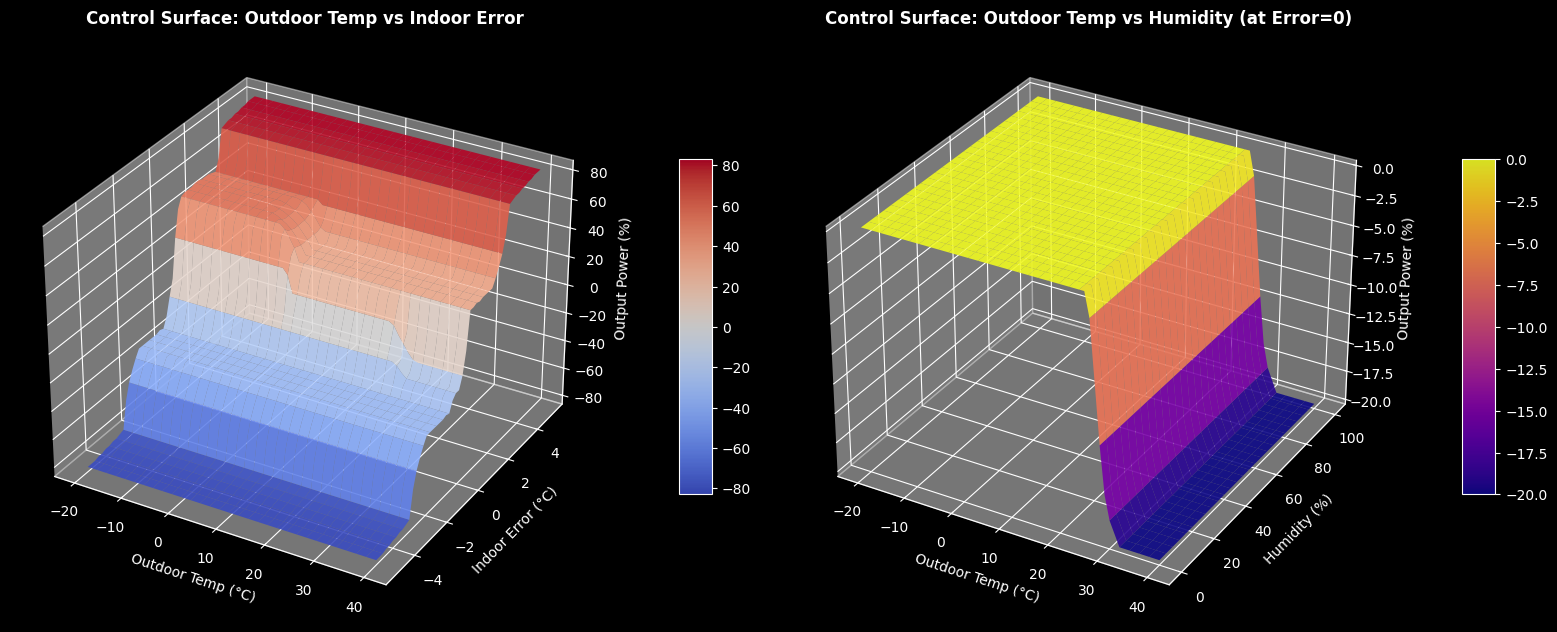

In [42]:
# ==============================================================================
# DISCRETIZATION AND SPACE CONFIGURATION (INPUT GRID GENERATION)
# ==============================================================================
# Define crisp input spaces matching the controller's universe of discourse boundaries
error_space = np.arange(-5, 5.1, 0.2)          # Step of 0.2 for optimal surface smoothness
outdoor_space = np.arange(-20, 41, 1)          # Spans full meteorological winter/summer range
humidity_space = np.arange(0, 101, 2)          # Standard relative humidity percentage array

# ------------------------------------------------------------------------------
# MESHGRID 1: Outdoor Temperature vs. Indoor Error
# ------------------------------------------------------------------------------
# Generate coordinate matrices for vector evaluation
O_e, E_o = np.meshgrid(outdoor_space, error_space)
Z_out_err = np.zeros_like(O_e)                 # Output control array matching grid dimensions

# Populate control surface data through iterative inference evaluation
for i in range(len(error_space)):
    for j in range(len(outdoor_space)):
        # Inject state variables into the Mamdani simulation container
        simulator.input['outdoor_temp'] = O_e[i, j]
        simulator.input['error'] = E_o[i, j]
        simulator.input['trend'] = 0.0          # Control assumption: Stable indoor climate
        simulator.input['humidity'] = 50.0       # Control assumption: Optimal indoor moisture

        try:
            simulator.compute()
            Z_out_err[i, j] = simulator.output['control_output']
        except KeyError:
            # Fallback Mechanism: Catch unhandled linguistic states and suppress exception.
            # Assigns 0.0% (Idle/Off) to prevent runtime crashes during mesh generation.
            Z_out_err[i, j] = 0.0

# ------------------------------------------------------------------------------
# MESHGRID 2: Outdoor Temperature vs. Indoor Humidity
# ------------------------------------------------------------------------------
O_h, H_o = np.meshgrid(outdoor_space, humidity_space)
Z_out_hum = np.zeros_like(O_h)

for i in range(len(humidity_space)):
    for j in range(len(outdoor_space)):
        # Inject state variables into the simulation container
        simulator.input['outdoor_temp'] = O_h[i, j]
        simulator.input['humidity'] = H_o[i, j]
        simulator.input['error'] = 0.0         # Control assumption: Setpoint is perfectly met
        simulator.input['trend'] = 0.0         # Control assumption: Zero temperature drift

        try:
            simulator.compute()
            Z_out_hum[i, j] = simulator.output['control_output']
        except KeyError:
            # Fallback Mechanism: Maintain safety deadband if state combination falls outside rules.
            Z_out_hum[i, j] = 0.0

# ==============================================================================
# DATA VISUALIZATION ENGINE (3D SURFACE PLOTTING)
# ==============================================================================
fig = plt.figure(figsize=(16, 7))

# --- Plot 1: Outdoor Temperature vs. Indoor Temperature Error ---
ax3 = fig.add_subplot(121, projection='3d')
# Plot using the 'coolwarm' colormap to clearly delineate heating (red) and cooling (blue) zones
surf3 = ax3.plot_surface(O_e, E_o, Z_out_err, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax3.set_title('Control Surface: Outdoor Temp vs Indoor Error', fontsize=12, fontweight='bold')
ax3.set_xlabel('Outdoor Temp (°C)')
ax3.set_ylabel('Indoor Error (°C)')
ax3.set_zlabel('Output Power (%)')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, pad=0.1)

# --- Plot 2: Outdoor Temperature vs. Indoor Relative Humidity ---
ax4 = fig.add_subplot(122, projection='3d')
# Plot using the high-contrast 'plasma' colormap for clear visualization of the multi-variable deadband
surf4 = ax4.plot_surface(O_h, H_o, Z_out_hum, cmap='plasma', edgecolor='none', alpha=0.9)
ax4.set_title('Control Surface: Outdoor Temp vs Humidity (at Error=0)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Outdoor Temp (°C)')
ax4.set_ylabel('Humidity (%)')
ax4.set_zlabel('Output Power (%)')
fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=10, pad=0.1)

# Apply global styling adjustments to eliminate multi-panel layout overlaps
plt.tight_layout()
plt.show()